# Set up Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from statsmodels.tsa.seasonal import STL
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [19]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.3, 'grid.linestyle': '--', 'figure.dpi': 150,
})
COLORS = {
    'blue': '#2563EB', 'orange': '#F97316', 'red': '#DC2626',
    'green': '#16A34A', 'amber': '#D97706', 'gray': '#6B7280',
    'teal': '#0891B2', 'purple': '#7C3AED', 'coral': '#EA580C',
}

In [20]:
DATA_DIR = 'Dataset/'
orders = pd.read_csv(DATA_DIR+'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR+'order_items.csv', low_memory=False)
products = pd.read_csv(DATA_DIR+'products.csv')
customers = pd.read_csv(DATA_DIR+'customers.csv', parse_dates=['signup_date'])
sales = pd.read_csv(DATA_DIR+'sales.csv', parse_dates=['Date'])
returns = pd.read_csv(DATA_DIR+'returns.csv', parse_dates=['return_date'])
payments = pd.read_csv(DATA_DIR+'payments.csv')
promotions = pd.read_csv(DATA_DIR+'promotions.csv', parse_dates=['start_date','end_date'])
geography = pd.read_csv(DATA_DIR+'geography.csv')
reviews = pd.read_csv(DATA_DIR+'reviews.csv')
shipments = pd.read_csv(DATA_DIR+'shipments.csv', parse_dates=['ship_date','delivery_date'])
inventory = pd.read_csv(DATA_DIR+'inventory.csv')
web_traffic = pd.read_csv(DATA_DIR+'web_traffic.csv', parse_dates=['date'])

In [21]:
sales['month'] = sales['Date'].dt.month
sales['year'] = sales['Date'].dt.year
orders['year'] = orders['order_date'].dt.year
customers['signup_year'] = customers['signup_date'].dt.year
items_prod = order_items.merge(products[['product_id','category','segment','size']], on='product_id')
items_prod['revenue'] = items_prod['unit_price']*items_prod['quantity'] - items_prod['discount_amount']
items_ord = items_prod.merge(orders[['order_id','order_date','order_status']], on='order_id')
items_ord['year'] = items_ord['order_date'].dt.year
geo_orders = orders.merge(geography[['zip','region']], on='zip', how='left')
print("Data loaded")

Data loaded


# EDA TẦNG 1: DESCRIPTIVE - "Chuyện gì đã xảy ra?"

## 1.1.1 Revenue, COGS, Gross Profit Trend and Seasonality

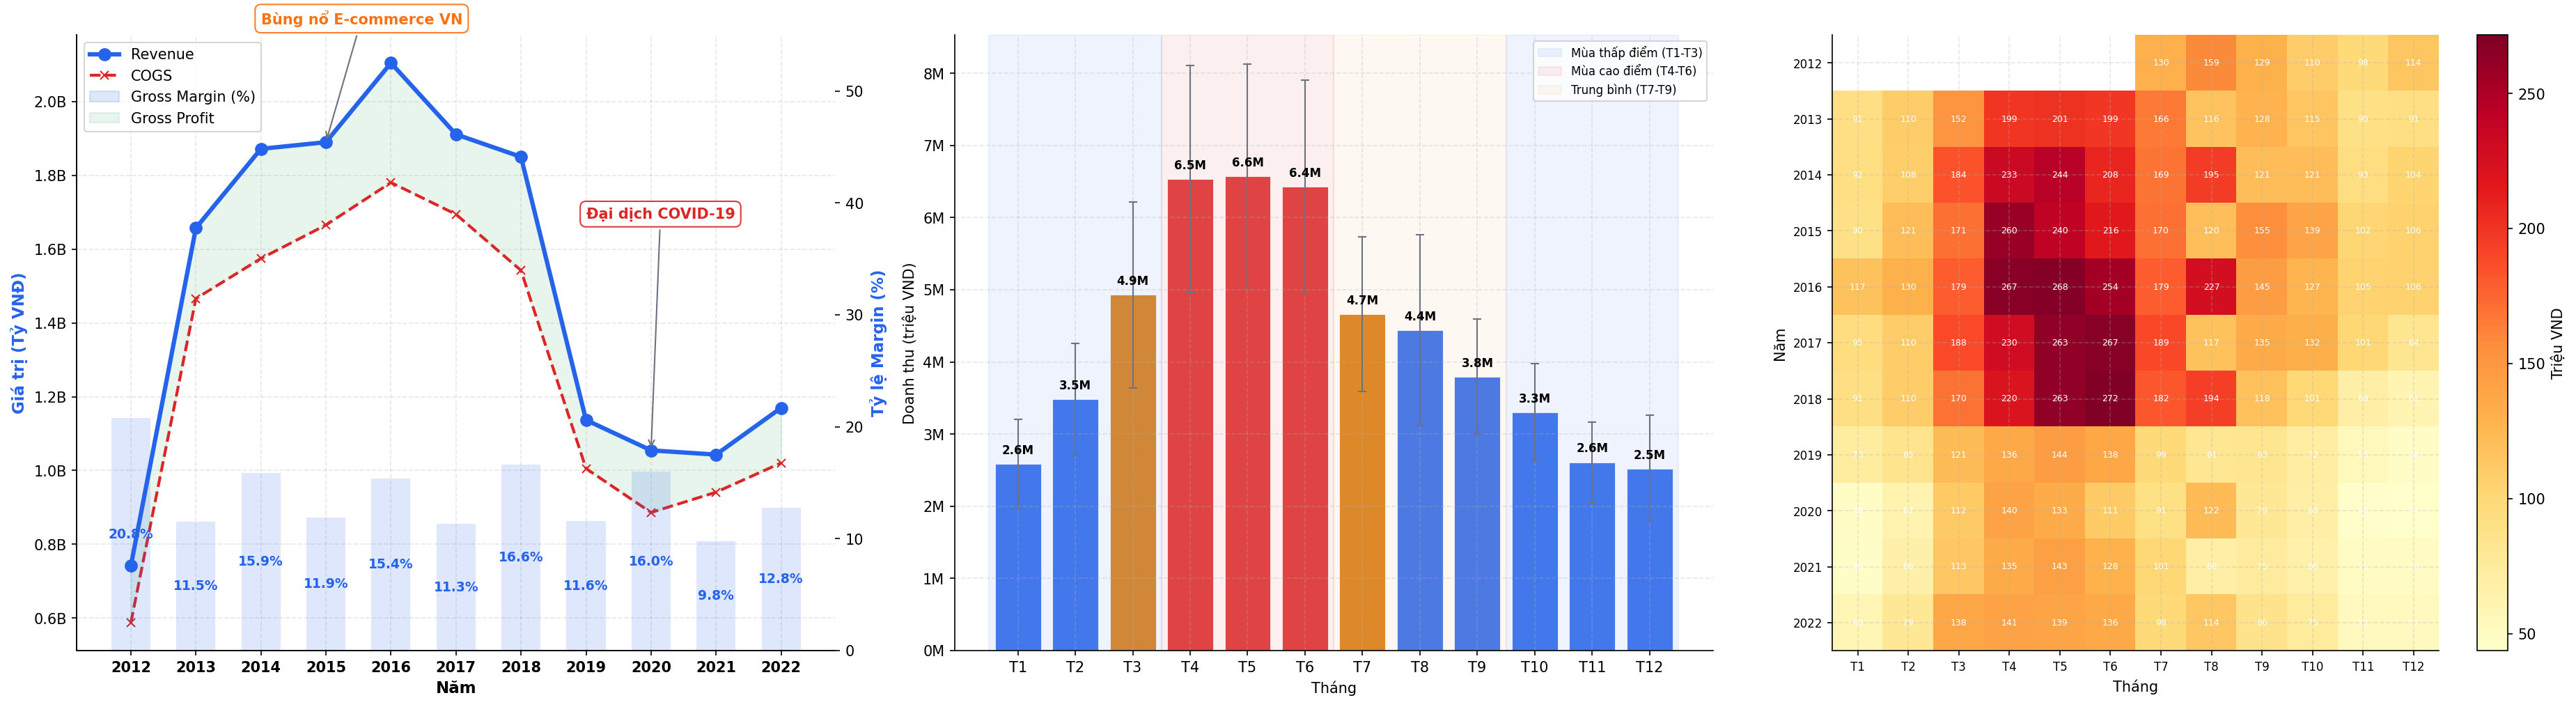

In [22]:
def plot_1_1():
    # --- 1.1 - Yearly Revenue, COGS and Gross Profit Trend (2012 - 2022) ---
    sales['Date'] = pd.to_datetime(sales['Date'])
    y_data = sales.groupby(sales['Date'].dt.year).agg({
        'Revenue': 'sum',
        'COGS': 'sum'
    }).reset_index()

    y_data['Gross_Profit'] = y_data['Revenue'] - y_data['COGS']
    y_data['Gross_Margin_Pct'] = (y_data['Gross_Profit'] / y_data['Revenue']) * 100
    rev_max = y_data['Revenue'].max()

    # --- 1.2 - Monthly Average Revenue and Heatmap ---
    monthly_avg  = sales.groupby('month')['Revenue'].mean() / 1e6
    monthly_std  = sales.groupby('month')['Revenue'].std()  / 1e6
    months_label = ['T1','T2','T3','T4','T5','T6',
                    'T7','T8','T9','T10','T11','T12']
    pivot = sales.pivot_table(index='year', columns='month', values='Revenue', aggfunc='sum') / 1e6

    # Create a figure with 3 subplots arranged horizontally
    fig = plt.figure(figsize=(25, 7)) # Adjusted figure size for horizontal layout
    gs = GridSpec(1, 3, figure=fig) # 1 row, 3 columns


    # --- Subplot 1: 1.1 Financial Trend ---
    ax1 = fig.add_subplot(gs[0, 0]) # First column
    ax1b = ax1.twinx()

    bars = ax1b.bar(y_data['Date'], y_data['Gross_Margin_Pct'],
                   color=COLORS['blue'], alpha=0.15,
                   label='Gross Margin (%)', width=0.6)

    for bar in bars:
        height = bar.get_height()
        ax1b.text(bar.get_x() + bar.get_width()/2, height / 2,
                 f'{height:.1f}%', ha='center', va='center',
                 fontsize=9, fontweight='bold', color=COLORS['blue'])

    line1, = ax1.plot(y_data['Date'], y_data['Revenue'],
                      color=COLORS['blue'], linewidth=3, label='Revenue', marker='o', markersize=8)
    line2, = ax1.plot(y_data['Date'], y_data['COGS'],
                      color=COLORS['red'], linewidth=2, label='COGS', marker='x', linestyle='--')

    ax1.fill_between(y_data['Date'], y_data['Revenue'], y_data['COGS'],
                     where=(y_data['Revenue'] >= y_data['COGS']),
                     color=COLORS['green'], alpha=0.1, label='Gross Profit Area')

    ax1.set_xticks(y_data['Date'])
    ax1.set_xticklabels(y_data['Date'].astype(int), fontweight='bold')
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'{x*1e-9:.1f}B'))
    ax1.set_ylabel("Giá trị (Tỷ VNĐ)", fontsize=11, fontweight='bold', color=COLORS['blue'])
    ax1.set_xlabel('Năm', fontsize=11, fontweight='bold')

    ax1b.set_ylabel("Tỷ lệ Margin (%)", fontsize=11, fontweight='bold', color=COLORS['blue'])
    ax1b.set_ylim(0, 55)
    ax1b.grid(False)

    rev_2015 = y_data.loc[y_data['Date'] == 2015, 'Revenue'].values[0]
    ax1.annotate('Bùng nổ E-commerce VN',
                 xy=(2015, rev_2015),
                 xytext=(2014, rev_max * 1.05), # Adjusted xytext y-coordinate
                 arrowprops=dict(arrowstyle='->', color=COLORS['gray'], connectionstyle="arc3,rad=0"),
                 fontsize=10, fontweight='bold', color=COLORS['orange'],
                 bbox=dict(boxstyle="round,pad=0.4", fc='white', ec=COLORS['orange'], alpha=0.9))

    rev_2020 = y_data.loc[y_data['Date'] == 2020, 'Revenue'].values[0]
    ax1.annotate('Đại dịch COVID-19',
                 xy=(2020, rev_2020),
                 xytext=(2019, rev_max * 0.8),
                 arrowprops=dict(arrowstyle='->', color=COLORS['gray'], connectionstyle="arc3,rad=0"),
                 fontsize=10, fontweight='bold', color=COLORS['red'],
                 bbox=dict(boxstyle="round,pad=0.4", fc='white', ec=COLORS['red'], alpha=0.9))

    legend_elements = [
        line1, line2,
        mpatches.Patch(color=COLORS['blue'], alpha=0.15, label='Gross Margin (%)'),
        mpatches.Patch(color=COLORS['green'], alpha=0.1, label='Gross Profit')
    ]
    ax1.legend(handles=legend_elements, loc='upper left', frameon=True, shadow=False)


    # --- Subplot 2: Monthly Average Revenue ---
    ax2 = fig.add_subplot(gs[0, 1]) # Second column
    bar_colors = [COLORS['red'] if v >= 6 else
                  COLORS['amber'] if v >= 4.5 else
                  COLORS['blue'] for v in monthly_avg]
    bars = ax2.bar(months_label, monthly_avg, color=bar_colors,
                  edgecolor='white', linewidth=0.5, alpha=0.85)

    ax2.errorbar(months_label, monthly_avg, yerr=monthly_std*0.5,
                fmt='none', ecolor=COLORS['gray'], capsize=3, linewidth=1)

    for bar, val in zip(bars, monthly_avg):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.1f}M', ha='center', va='bottom', fontsize=8, fontweight='bold')

    ax2.set_ylabel('Doanh thu (triệu VND)')
    ax2.set_xlabel('Tháng')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}M'))

    ax2.axvspan(-0.5, 2.5,  alpha=0.07, color=COLORS['blue'],  label='Mùa thấp điểm (T1-T3)')
    ax2.axvspan(2.5,  5.5,  alpha=0.07, color=COLORS['red'],   label='Mùa cao điểm (T4-T6)')
    ax2.axvspan(5.5,  8.5,  alpha=0.05, color=COLORS['amber'],  label='Trung bình (T7-T9)')
    ax2.axvspan(8.5, 11.5,  alpha=0.07, color=COLORS['blue'])
    ax2.legend(fontsize=8, loc='upper right')

    # --- Subplot 3: Heatmap Monthly Revenue ---
    ax3 = fig.add_subplot(gs[0, 2]) # Third column
    im = ax3.imshow(pivot.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
    ax3.set_xticks(range(12))
    ax3.set_xticklabels(months_label, fontsize=8)
    ax3.set_yticks(range(len(pivot.index)))
    ax3.set_yticklabels(pivot.index.astype(int), fontsize=8) # Ensure labels are int
    ax3.set_xlabel('Tháng')
    ax3.set_ylabel('Năm')
    plt.colorbar(im, ax=ax3, label='Triệu VND')

    for i in range(len(pivot.index)):
        for j in range(12):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax3.text(j, i, f'{val:.0f}', ha='center', va='center',
                         fontsize=6, color='black' if val < 8 else 'white')

    plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust rect to make space for suptitle
    plt.savefig('Figures/plot1_1.png', bbox_inches='tight', dpi=150)
    plt.show()

plot_1_1()

Doanh thu tăng +123.5% trong năm 2013, nhưng biên lợi nhuận gộp (gross margin) lại giảm mạnh từ 20.8% xuống 11.5%. (*chỗ này data 2012 bắt đầu từ tháng 7 th nguyên năm 2012 có mỗi 6 tháng thì dĩ nhiên thua nguyên năm 2013 sum cả năm nên dthu 1 lèo đi lên là phải, chủ yếu qan tâm biên ln gộp)ban đầu vẽ theo quý mà nhìn dị tật nên ko lấy*
Suốt 11 năm, biên lợi nhuận gộp không có xu hướng cải thiện bền vững mà dao động theo chu kỳ: các năm cao trên 15% xen kẽ các năm thấp dưới 12%. Doanh nghiệp đang vận hành trong vòng lặp khuyến mãi kéo doanh thu nhưng kéo theo sụt giảm biên lợi nhuận, thay vì xây dựng sức mạnh định giá (pricing power) thực sự.
Doanh thu giảm -38.6% năm 2019, trước khi COVID-19 xảy ra. Giai đoạn này trùng với thời điểm các sàn thương mại điện tử lớn (Shopee, Lazada) mở rộng mạnh tại Việt Nam từ 2017–2018. Đây là dấu hiệu áp lực cạnh tranh mang tính cấu trúc (structural competition), không phải yếu tố chu kỳ hay vĩ mô.
Tỷ lệ doanh thu trên giá vốn dao động trong biên hẹp suốt 11 năm, kể cả khi doanh thu tăng gấp đôi giai đoạn 2012–2016. Giá vốn tăng gần tuyến tính theo doanh thu, cho thấy doanh nghiệp chưa khai thác được lợi thế kinh tế theo quy mô (economies of scale) - cấu trúc chi phí còn cứng nhắc.

**KEY INSIGHT**: Tháng 5 cao nhất (6.6M), tháng 12 thấp nhất (2.5M), ratio 2.6×
=>Tháng 1-3 là 'dead season' — cơ hội tung khuyến mãi kích cầu

## 1.1.2 Order Structure and Cancellation rate by payment method

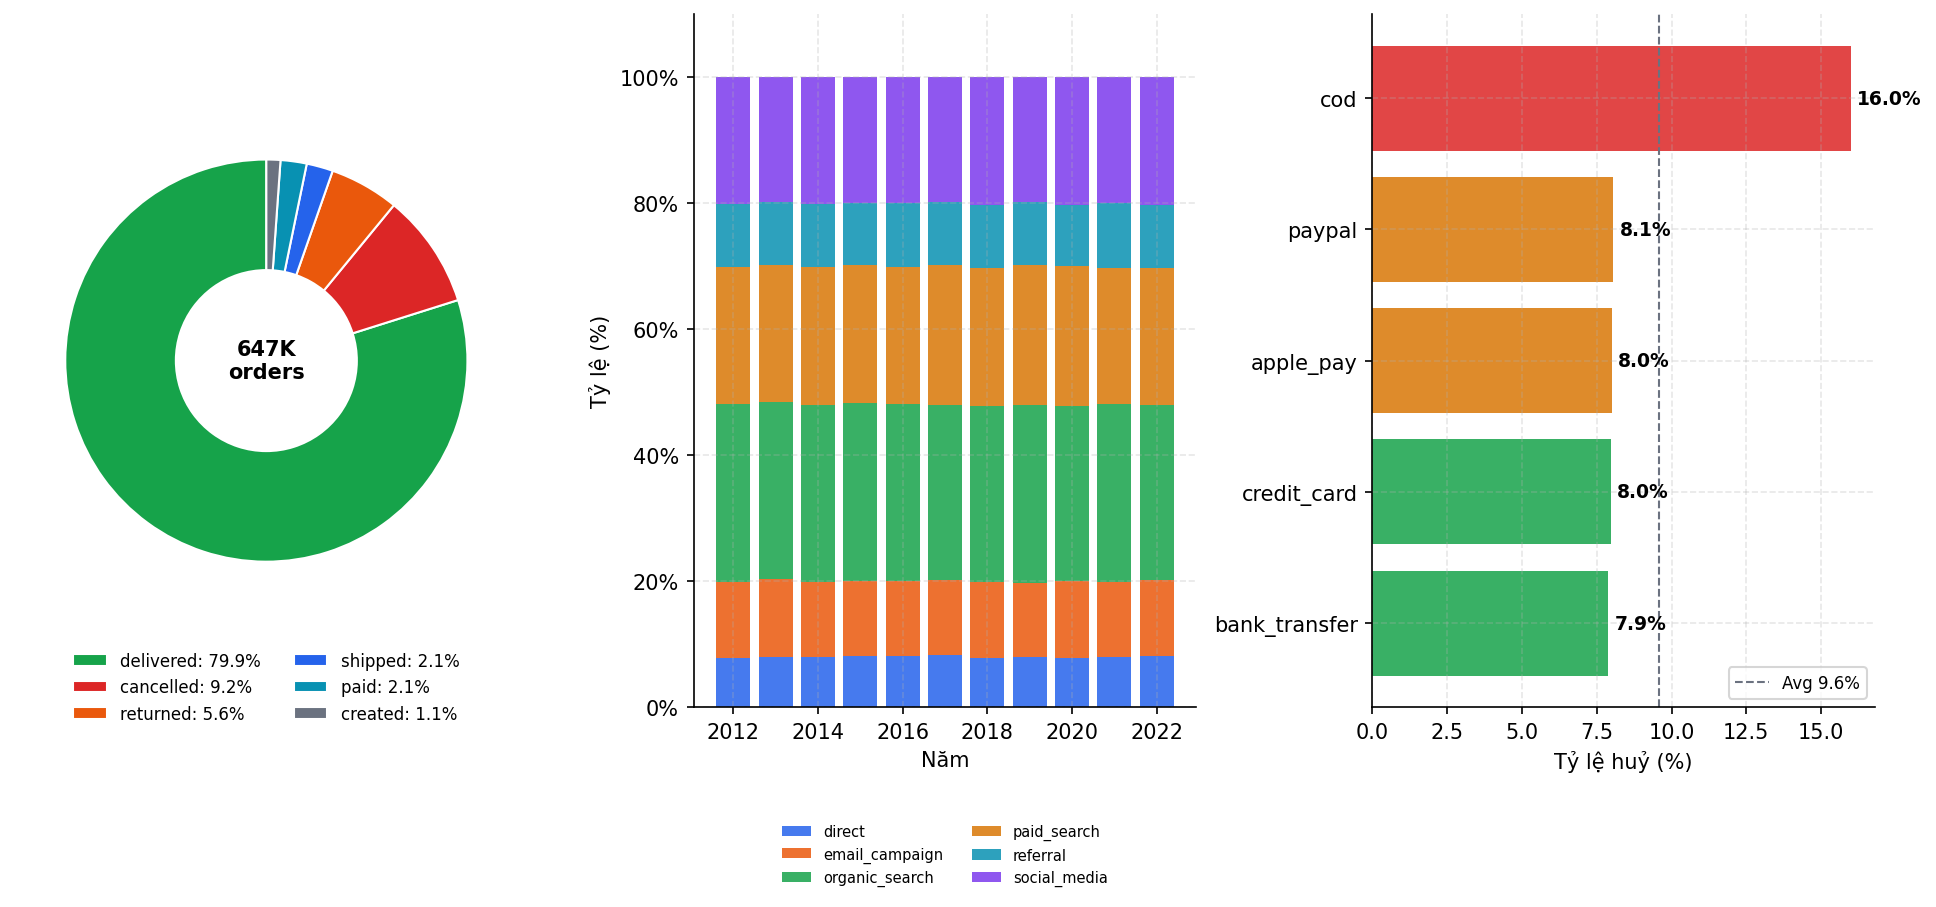

In [23]:
def plot_1_2():
    fig = plt.figure(figsize=(16, 6)) # Tăng chiều cao một chút để có chỗ cho legend phía dưới
    gs  = GridSpec(1, 3, figure=fig, wspace=0.35)

    # -- Sub 1: Order status donut --
    ax1 = fig.add_subplot(gs[0])
    status_cnt = orders['order_status'].value_counts()
    status_pct = (status_cnt / status_cnt.sum() * 100)
    
    status_colors = [COLORS['green'], COLORS['red'], COLORS['coral'],
                     COLORS['blue'], COLORS['teal'], COLORS['gray']]
    
    legend_labels = [f'{n}: {p:.1f}%' for n, p in zip(status_cnt.index, status_pct)]

    wedges, texts = ax1.pie(
        status_cnt.values,
        labels=None,
        autopct=None,
        colors=status_colors[:len(status_cnt)],
        wedgeprops=dict(width=0.55, edgecolor='w'),
        startangle=90
    )
    
    # Dịch legend xuống dưới hẳn biểu đồ (loc="upper center", bbox_to_anchor=(0.5, -0.05))
    ax1.legend(wedges, legend_labels, loc="upper center", 
               bbox_to_anchor=(0.5, -0.05), fontsize=8, frameon=False, ncol=2)

    ax1.text(0, 0, f'{len(orders)/1e3:.0f}K\norders',
             ha='center', va='center', fontsize=10, fontweight='bold')

    # -- Sub 2: Order source stacked --
    ax2 = fig.add_subplot(gs[1])
    source_yr = orders.groupby(['year','order_source'])['order_id'].count().unstack(fill_value=0)
    source_pct_df = source_yr.div(source_yr.sum(axis=1), axis=0) * 100
    
    source_colors = {
        'direct': COLORS['blue'], 'organic_search': COLORS['green'],
        'paid_search': COLORS['amber'], 'social_media': COLORS['purple'],
        'email_campaign': COLORS['coral'], 'referral': COLORS['teal']
    }

    bottom = np.zeros(len(source_pct_df))
    for col in source_pct_df.columns:
        ax2.bar(source_pct_df.index, source_pct_df[col], bottom=bottom,
                color=source_colors.get(col, COLORS['gray']), label=col, alpha=0.85)
        bottom += source_pct_df[col].values
    
    ax2.set_ylabel('Tỷ lệ (%)')
    ax2.set_xlabel('Năm')
    # Thu gọn legend của sub 2 để tránh lấn sang sub 3
    ax2.legend(fontsize=7, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)
    ax2.set_ylim(0, 110)
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}%'))

    # -- Sub 3: Cancellation rate by payment method --
    ax3 = fig.add_subplot(gs[2])
    # Tỷ lệ hủy đơn COD (16%) cao gấp đôi các phương thức khác
    cancel_pay = orders.groupby('payment_method').apply(
        lambda x: (x['order_status']=='cancelled').sum()/len(x)*100
    ).sort_values(ascending=True)
    
    bar_c = [COLORS['red'] if v > 10 else COLORS['amber'] if v > 8 else COLORS['green']
             for v in cancel_pay.values]
    hbars = ax3.barh(cancel_pay.index, cancel_pay.values, color=bar_c, alpha=0.85)
    
    for bar, val in zip(hbars, cancel_pay.values):
        ax3.text(val + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
                 
    ax3.axvline(x=cancel_pay.mean(), color=COLORS['gray'], linestyle='--',
                linewidth=1, label=f'Avg {cancel_pay.mean():.1f}%')
    ax3.set_xlabel('Tỷ lệ huỷ (%)')
    ax3.legend(fontsize=8, loc='lower right')

    # Chỉnh layout để không bị cắt mất legend nằm ngoài
    plt.tight_layout()
    # Xuất ảnh chuẩn cho LaTeX
    plt.savefig('Figures/plot1_2.png', bbox_inches='tight', dpi=300)
    plt.show()

plot_1_2()

**KEY INSIGHT**: COD cancellation 16% — gấp 2 lần các PTTT khác")
=>COD là PT có mức độ hủy đơn cao nhất — cần policy đặt cọc hoặc giới hạn COD")

# EDA TẦNG 2: DIAGNOSTIC - "Tại sao lại xảy ra?"

## 1.2.1 Returns Root Cause

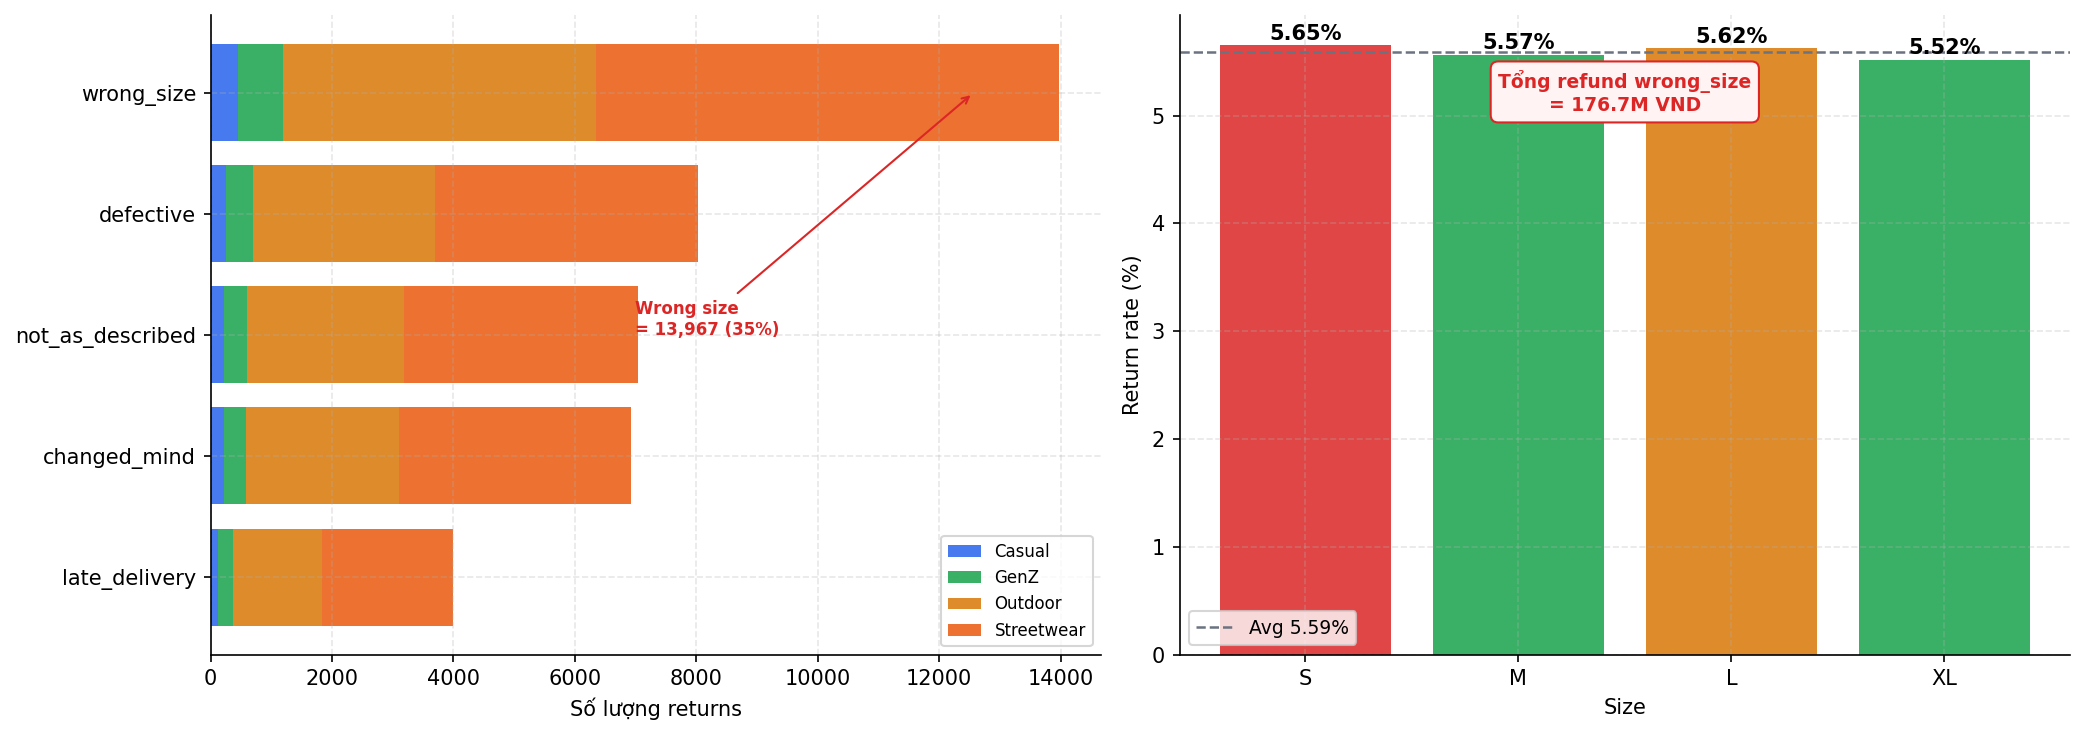

In [24]:
def plot_2_1():
    ret_prod = returns.merge(products[['product_id','category','size']], on='product_id')

    # Xóa tiêu đề chính của figure
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # -- Sub 1: Return reason stacked by category --
    ax1 = axes[0]
    reason_cat = ret_prod.groupby(['return_reason','category'])['return_id'].count().unstack(fill_value=0)
    reason_cat_sorted = reason_cat.sum(axis=1).sort_values(ascending=True)
    reason_cat = reason_cat.loc[reason_cat_sorted.index]

    cat_colors2 = [COLORS['blue'], COLORS['green'], COLORS['amber'], COLORS['coral']]
    bottom2 = np.zeros(len(reason_cat))
    for i, cat in enumerate(reason_cat.columns):
        ax1.barh(reason_cat.index, reason_cat[cat], left=bottom2,
                 color=cat_colors2[i], alpha=0.85, label=cat)
        bottom2 += reason_cat[cat].values

    ax1.set_xlabel('Số lượng returns')
    # ax1.set_title(...) -> Đã xóa
    ax1.legend(fontsize=8)

    # Annotation wrong_size (Dựa trên số liệu: 35% ~ 13,967 yêu cầu)
    ws_total = reason_cat.loc['wrong_size'].sum()
    ax1.annotate(f'Wrong size\n= {ws_total:,} ({ws_total/ret_prod.shape[0]*100:.0f}%)',
                 xy=(ws_total*0.9, 'wrong_size'),
                 xytext=(ws_total*0.5, 'not_as_described'),
                 fontsize=8, color=COLORS['red'], fontweight='bold',
                 arrowprops=dict(arrowstyle='->', color=COLORS['red']))

    # -- Sub 2: Return rate by size --
    ax2 = axes[1]
    ret_size = ret_prod.groupby('size')['return_id'].count()
    oi_size  = items_prod.groupby('size')['order_id'].count()
    sizes_common = ['S', 'M', 'L', 'XL']

    ret_rate_size = pd.Series({
        s: ret_size.get(s, 0) / oi_size.get(s, 1) * 100
        for s in sizes_common
    })

    bar_c3 = [COLORS['red'] if v == ret_rate_size.max() else COLORS['amber']
               if v > ret_rate_size.mean() else COLORS['green']
               for v in ret_rate_size.values]
    b3 = ax2.bar(ret_rate_size.index, ret_rate_size.values, color=bar_c3, alpha=0.85)

    for bar, val in zip(b3, ret_rate_size.values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

    ax2.axhline(ret_rate_size.mean(), color=COLORS['gray'], linestyle='--',
                linewidth=1.2, label=f'Avg {ret_rate_size.mean():.2f}%')
    # ax2.set_title(...) -> Đã xóa
    ax2.set_ylabel('Return rate (%)')
    ax2.set_xlabel('Size')
    ax2.legend(fontsize=9)

    # Refund impact estimate
    ws_refund = returns[returns['return_reason']=='wrong_size']['refund_amount'].sum()
    ax2.text(0.5, 0.85,
             f"Tổng refund wrong_size\n= {ws_refund/1e6:.1f}M VND",
             transform=ax2.transAxes, ha='center', fontsize=9,
             color=COLORS['red'], fontweight='bold',
             bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF3F3', edgecolor=COLORS['red']))

    plt.tight_layout()
    # Lưu vào thư mục figures/ để khớp với lệnh chèn hình trong LaTeX[cite: 2]
    plt.savefig('Figures/plot2_1.png', bbox_inches='tight', dpi=300)
    plt.show()

plot_2_1()

  **KEY INSIGHT:**
- wrong_size = 35% tổng returns (13,967/39,939)
- Tập trung ở Outdoor (5,154) và Streetwear (7,626)
- Đây là vấn đề CÓ THỂ fix được bằng size guide → tiết kiệm khoản refund

## 1.2.2 Web Traffic → Conversion (Deep Dive)

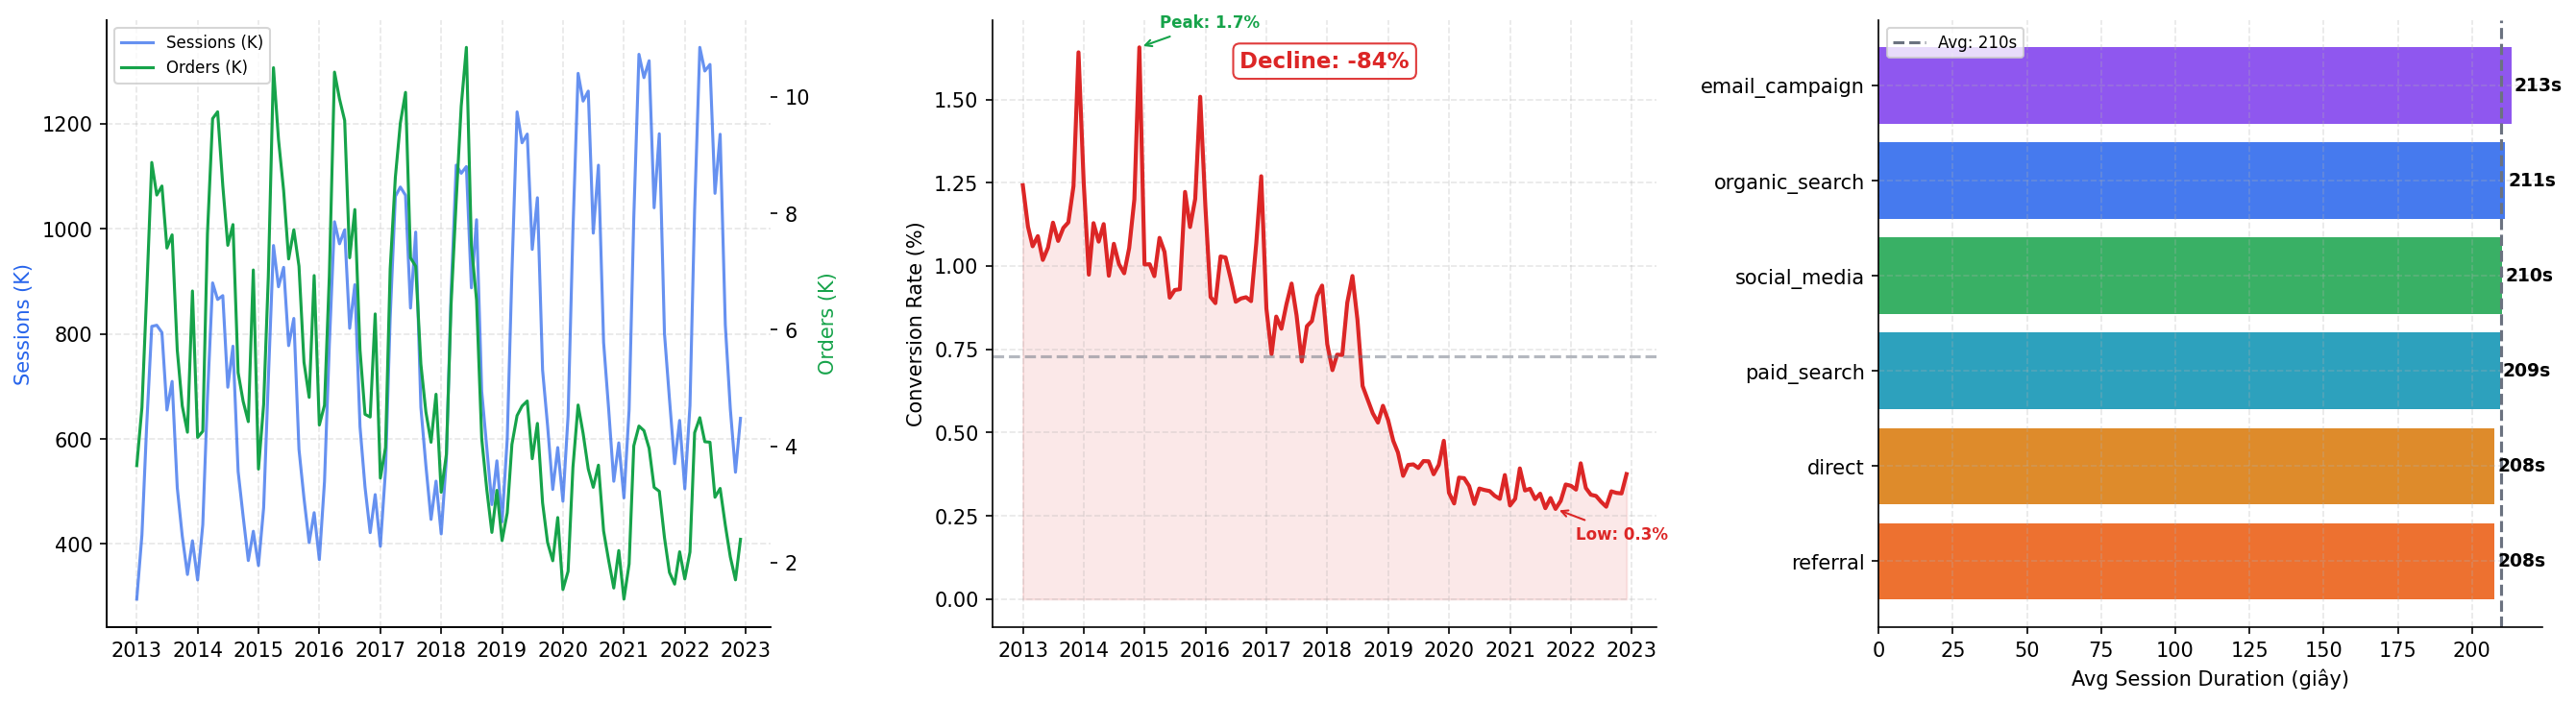

In [25]:
# === 2.4 Web Traffic → Conversion (Clean version for LaTeX) ===
def plot_2_2():
    wt = web_traffic.copy()
    wt['year_month'] = wt['date'].dt.to_period('M')
    wt_m = wt.groupby('year_month').agg({'sessions':'sum','unique_visitors':'sum'}).reset_index()
    wt_m['year_month'] = wt_m['year_month'].dt.to_timestamp()
    ord_m = orders.groupby(orders['order_date'].dt.to_period('M'))['order_id'].nunique().reset_index()
    ord_m.columns = ['year_month','n_orders']
    ord_m['year_month'] = ord_m['year_month'].dt.to_timestamp()
    merged = wt_m.merge(ord_m, on='year_month', how='inner')
    merged['conv_rate'] = merged['n_orders'] / merged['sessions'] * 100

    # Traffic source quality
    src = wt.groupby('traffic_source').agg(
        total_sessions=('sessions','sum'),
        avg_duration=('avg_session_duration_sec','mean')).sort_values('avg_duration', ascending=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Panel 1: Sessions vs Orders
    ax1 = axes[0]
    ax1b = ax1.twinx()
    ax1.plot(merged['year_month'], merged['sessions']/1e3, color=COLORS['blue'], lw=1.5, alpha=0.7, label='Sessions (K)')
    ax1b.plot(merged['year_month'], merged['n_orders']/1e3, color=COLORS['green'], lw=1.5, label='Orders (K)')
    ax1.set_ylabel('Sessions (K)', color=COLORS['blue'])
    ax1b.set_ylabel('Orders (K)', color=COLORS['green']); ax1b.grid(False)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax1b.get_legend_handles_labels()
    ax1.legend(h1+h2, l1+l2, fontsize=8, loc='upper left')

    # Panel 2: Conversion Rate with annotations
    ax2 = axes[1]
    ax2.plot(merged['year_month'], merged['conv_rate'], color=COLORS['red'], lw=2)
    ax2.axhline(merged['conv_rate'].mean(), color=COLORS['gray'], ls='--', alpha=0.5)
    ax2.fill_between(merged['year_month'], merged['conv_rate'], alpha=0.1, color=COLORS['red'])
    peak_idx = merged['conv_rate'].idxmax()
    trough_idx = merged['conv_rate'].idxmin()
    peak_val = merged.loc[peak_idx, 'conv_rate']
    trough_val = merged.loc[trough_idx, 'conv_rate']
    ax2.annotate(f'Peak: {peak_val:.1f}%', xy=(merged.loc[peak_idx,'year_month'], peak_val),
                 xytext=(10, 10), textcoords='offset points', fontsize=8, fontweight='bold',
                 color=COLORS['green'], arrowprops=dict(arrowstyle='->', color=COLORS['green']))
    ax2.annotate(f'Low: {trough_val:.1f}%', xy=(merged.loc[trough_idx,'year_month'], trough_val),
                 xytext=(10, -15), textcoords='offset points', fontsize=8, fontweight='bold',
                 color=COLORS['red'], arrowprops=dict(arrowstyle='->', color=COLORS['red']))
    decline_pct = (trough_val / peak_val - 1) * 100
    ax2.text(0.5, 0.95, f'Decline: {decline_pct:.0f}%', transform=ax2.transAxes, fontsize=11,
             fontweight='bold', color=COLORS['red'], ha='center', va='top',
             bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=COLORS['red'], alpha=0.9))
    ax2.set_ylabel('Conversion Rate (%)')

    # Panel 3: Avg Session Duration
    ax3 = axes[2]
    src_colors = [COLORS['coral'], COLORS['amber'], COLORS['teal'], COLORS['green'], COLORS['blue'], COLORS['purple']]
    bars = ax3.barh(src.index, src['avg_duration'], color=src_colors[:len(src)], alpha=0.85)
    for b, v in zip(bars, src['avg_duration']):
        ax3.text(v+1, b.get_y()+b.get_height()/2, f'{v:.0f}s', va='center', fontsize=9, fontweight='bold')
    ax3.set_xlabel('Avg Session Duration (giây)')
    ax3.axvline(src['avg_duration'].mean(), color=COLORS['gray'], ls='--',
                label=f"Avg: {src['avg_duration'].mean():.0f}s")
    ax3.legend(fontsize=8)

    plt.tight_layout()
    
    # Xuất file ảnh (đảm bảo thư mục 'figures' đã tồn tại trong máy bạn)
    plt.savefig('Figures/plot2_2.png', dpi=300, bbox_inches='tight')
    plt.show()

plot_2_2()

**KEY INSIGHT:** Conversion sụt 84% (peak 1.7% → low 0.3%).
-  Sessions tăng nhưng orders không tăng tương ứng → traffic chất lượng kém.
-  Traffic source chất lượng nhất (session dài nhất): email_campaign (213s)

# EDA TẦNG 3: PREDICTIVE - "Điều gì sẽ xảy ra?"

## 1.3.1 STL Decomposition (Phân rã chuỗi thời gian)

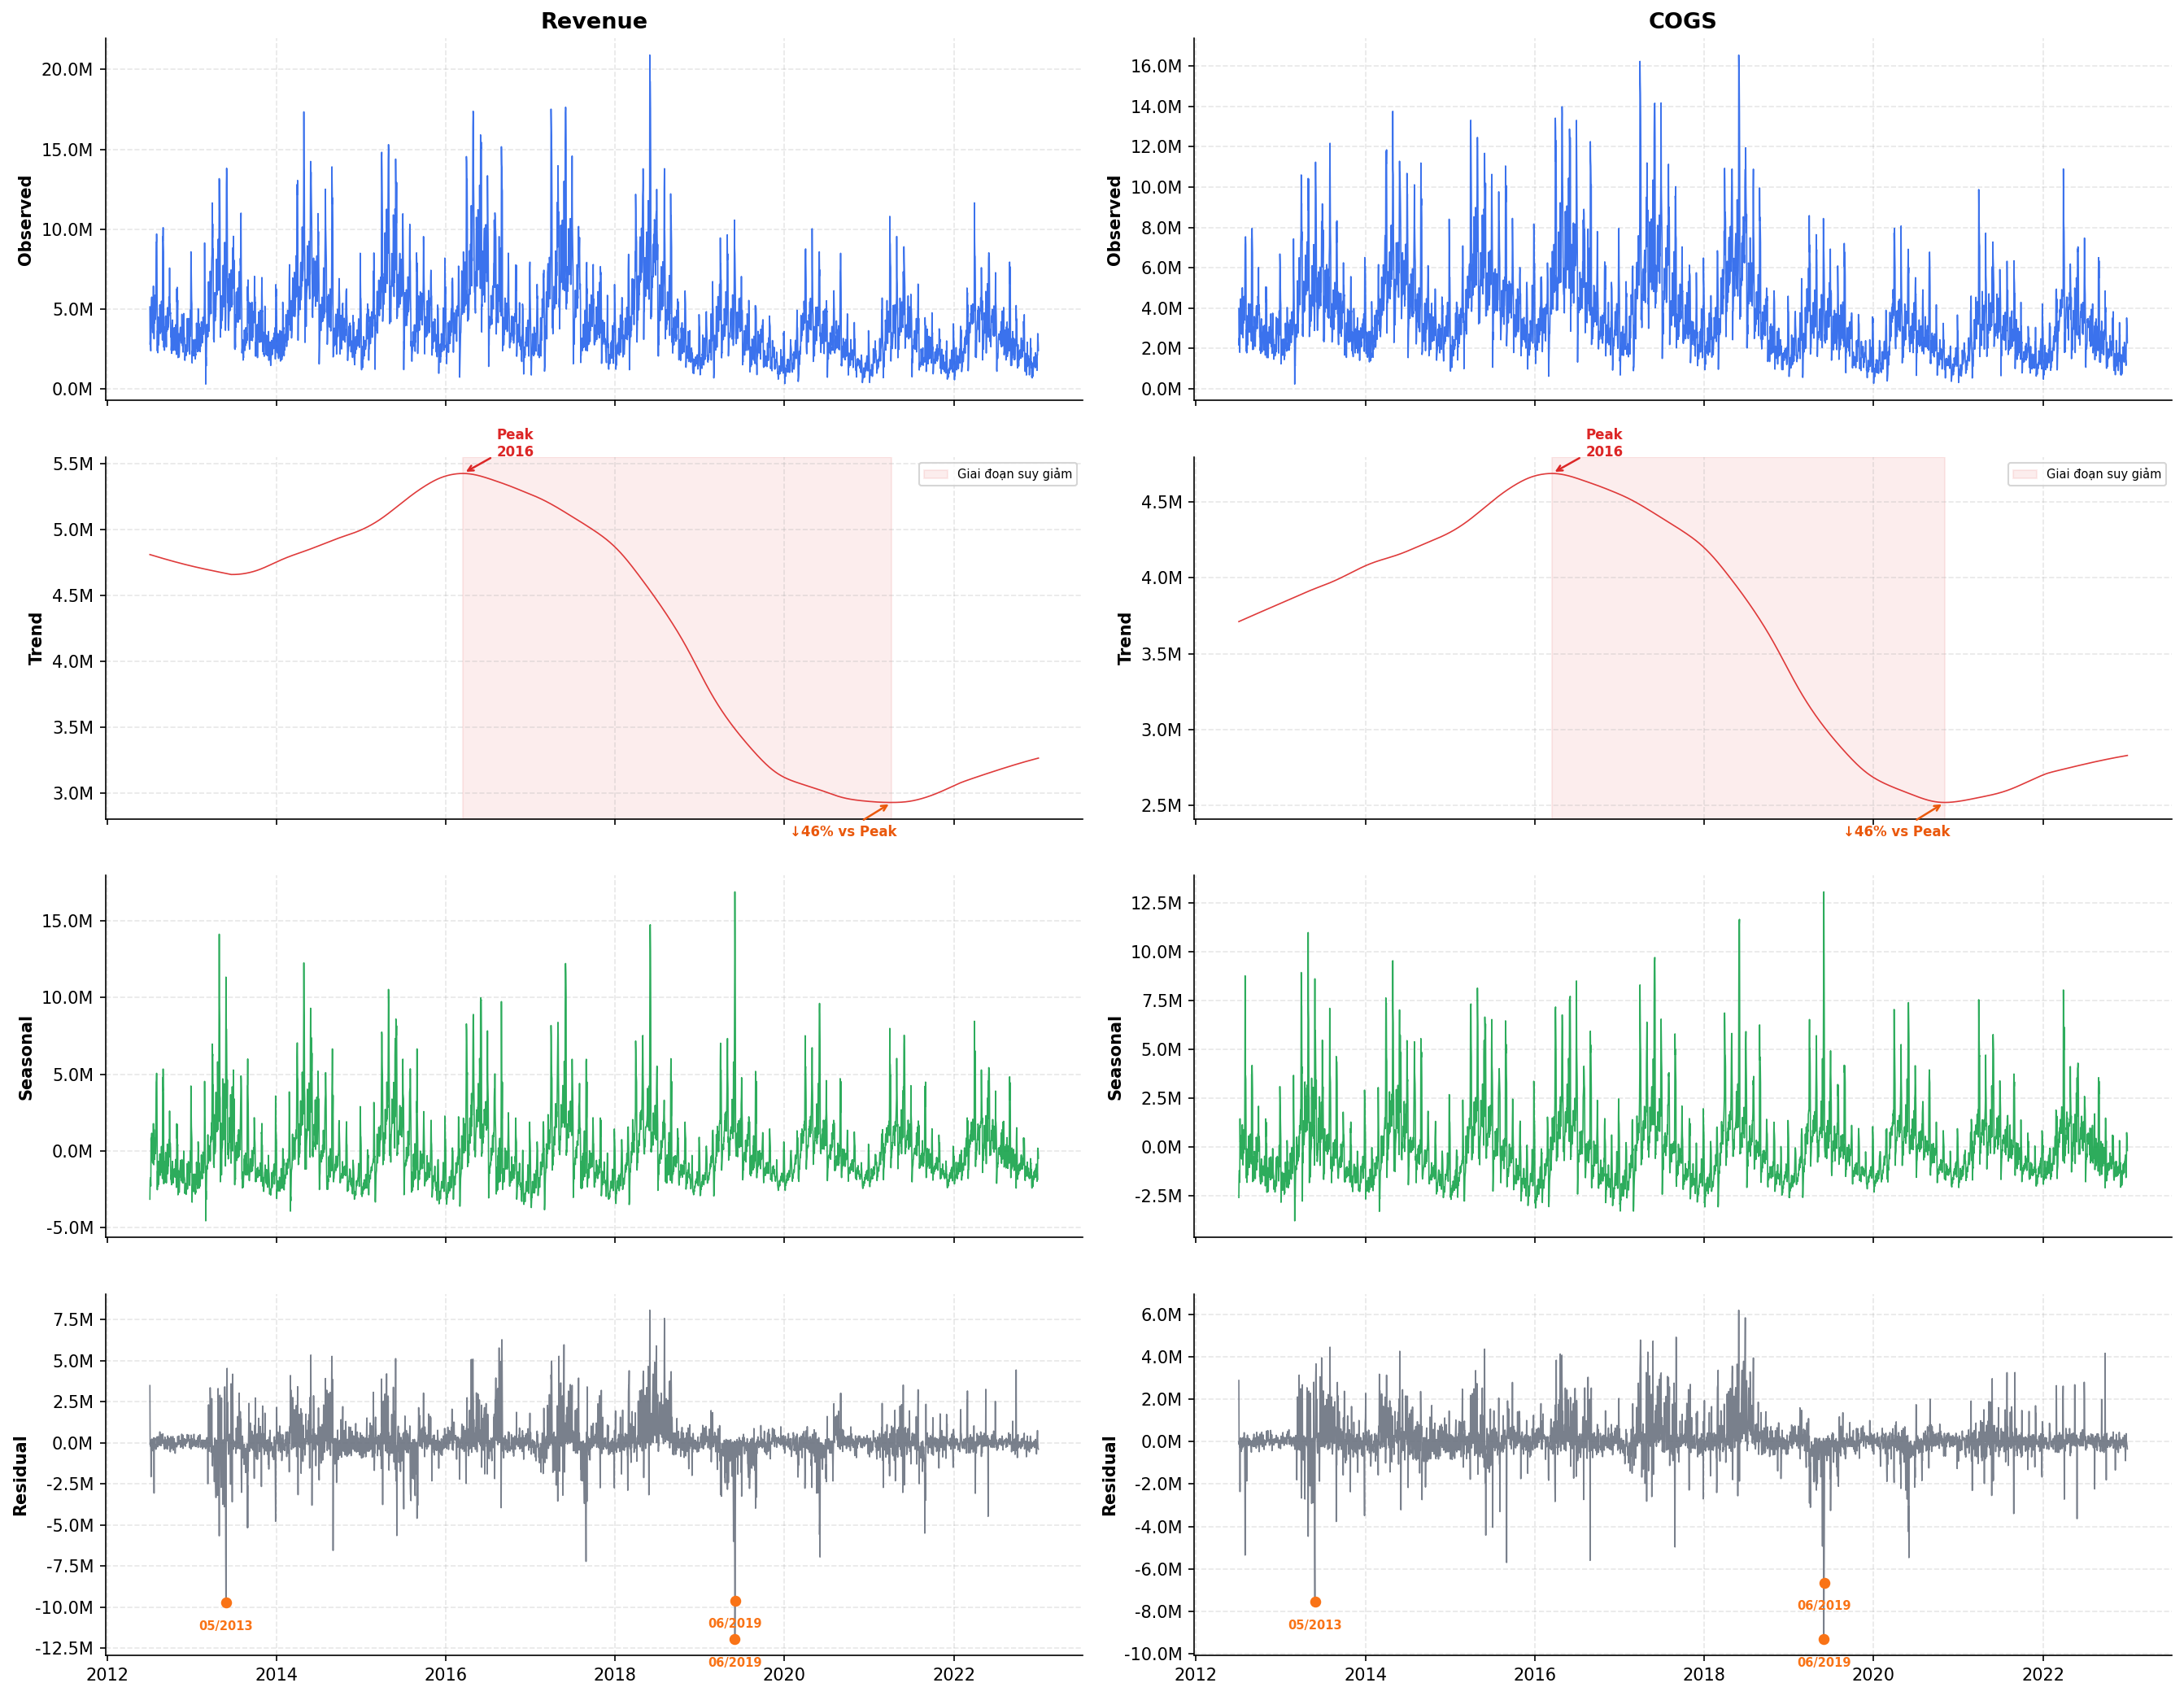

In [26]:
# === 3.1 STL Decomposition (Version for LaTeX) ===
def plot_3_1():
    ts = sales.set_index('Date').sort_index()
    fig, axes = plt.subplots(4, 2, figsize=(18, 14), sharex=True)
    # fig.suptitle(...) -> Đã xóa tiêu đề chính để dùng caption trong LaTeX

    for ci, target in enumerate(['Revenue', 'COGS']):
        result = STL(ts[target], period=365, robust=True).fit()
        components = [
            ('Observed', ts[target],     COLORS['blue']),
            ('Trend',    result.trend,   COLORS['red']),
            ('Seasonal', result.seasonal, COLORS['green']),
            ('Residual', result.resid,   COLORS['gray']),
        ]
        for ri, (lbl, data, clr) in enumerate(components):
            ax = axes[ri, ci]
            ax.plot(data, color=clr, lw=0.8, alpha=0.9)
            ax.set_ylabel(lbl, fontsize=10, fontweight='bold')
            if ri == 0:
                # Vẫn giữ title của từng cột để phân biệt Revenue và COGS
                ax.set_title(target, fontsize=13, fontweight='bold')
            ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

            # --- Annotations on TREND row ---
            if ri == 1:
                trend_s = pd.Series(data.values, index=data.index)
                peak_date = trend_s.idxmax()
                trough_date = trend_s.idxmin()
                peak_val = trend_s.max()
                trough_val = trend_s.min()
                decline_pct = (trough_val / peak_val - 1) * 100

                # Peak marker
                ax.annotate(f'Peak\n{peak_date.year}',
                            xy=(peak_date, peak_val),
                            xytext=(20, 10), textcoords='offset points',
                            fontsize=8, fontweight='bold', color=COLORS['red'],
                            arrowprops=dict(arrowstyle='->', color=COLORS['red'], lw=1.2))

                # Decline label at trough
                ax.annotate(f'↓{abs(decline_pct):.0f}% vs Peak',
                            xy=(trough_date, trough_val),
                            xytext=(-60, -20), textcoords='offset points',
                            fontsize=8, fontweight='bold', color=COLORS['coral'],
                            arrowprops=dict(arrowstyle='->', color=COLORS['coral'], lw=1.2))

                # Shade decline period
                ax.axvspan(peak_date, trough_date, alpha=0.08, color=COLORS['red'],
                           label='Giai đoạn suy giảm')
                ax.legend(fontsize=7, loc='upper right')

            # --- Annotations on RESIDUAL row ---
            if ri == 3:
                resid_s = pd.Series(data.values, index=data.index)
                # Mark top 3 outliers
                top_outliers = resid_s.abs().nlargest(3)
                for od, ov in zip(top_outliers.index, top_outliers.values * np.sign(resid_s[top_outliers.index])):
                    ax.annotate(f'{od.strftime("%m/%Y")}',
                                xy=(od, ov),
                                xytext=(0, 12 if ov > 0 else -16), textcoords='offset points',
                                fontsize=7, color=COLORS['orange'], fontweight='bold',
                                ha='center')
                    ax.scatter([od], [ov], color=COLORS['orange'], s=30, zorder=5)

    plt.tight_layout() # Đã bỏ rect=[0, 0, 1, 0.97] vì không còn suptitle
    
    # Xuất ảnh DPI cao cho báo cáo Datathon 2026
    plt.savefig('Figures/plot3_1.png', bbox_inches='tight', dpi=300)
    plt.show()

plot_3_1()

**KEY INSIGHT (Predictive):**
- Trend đang giảm: nếu không có can thiệp, Revenue 2023-2024 dự kiến tiếp tục giảm ~5-8%/năm.
- Seasonal component cho thấy các tháng cuối năm sẽ cao hơn baseline ~2-3x → tập trung inventory & promo vào Q4.
- Residual outliers cần được loại bỏ hoặc xử lý trước khi đưa vào model dự báo để tránh bias.

## 1.3.2 RFM Customer Segmentation and Churn Analysis 

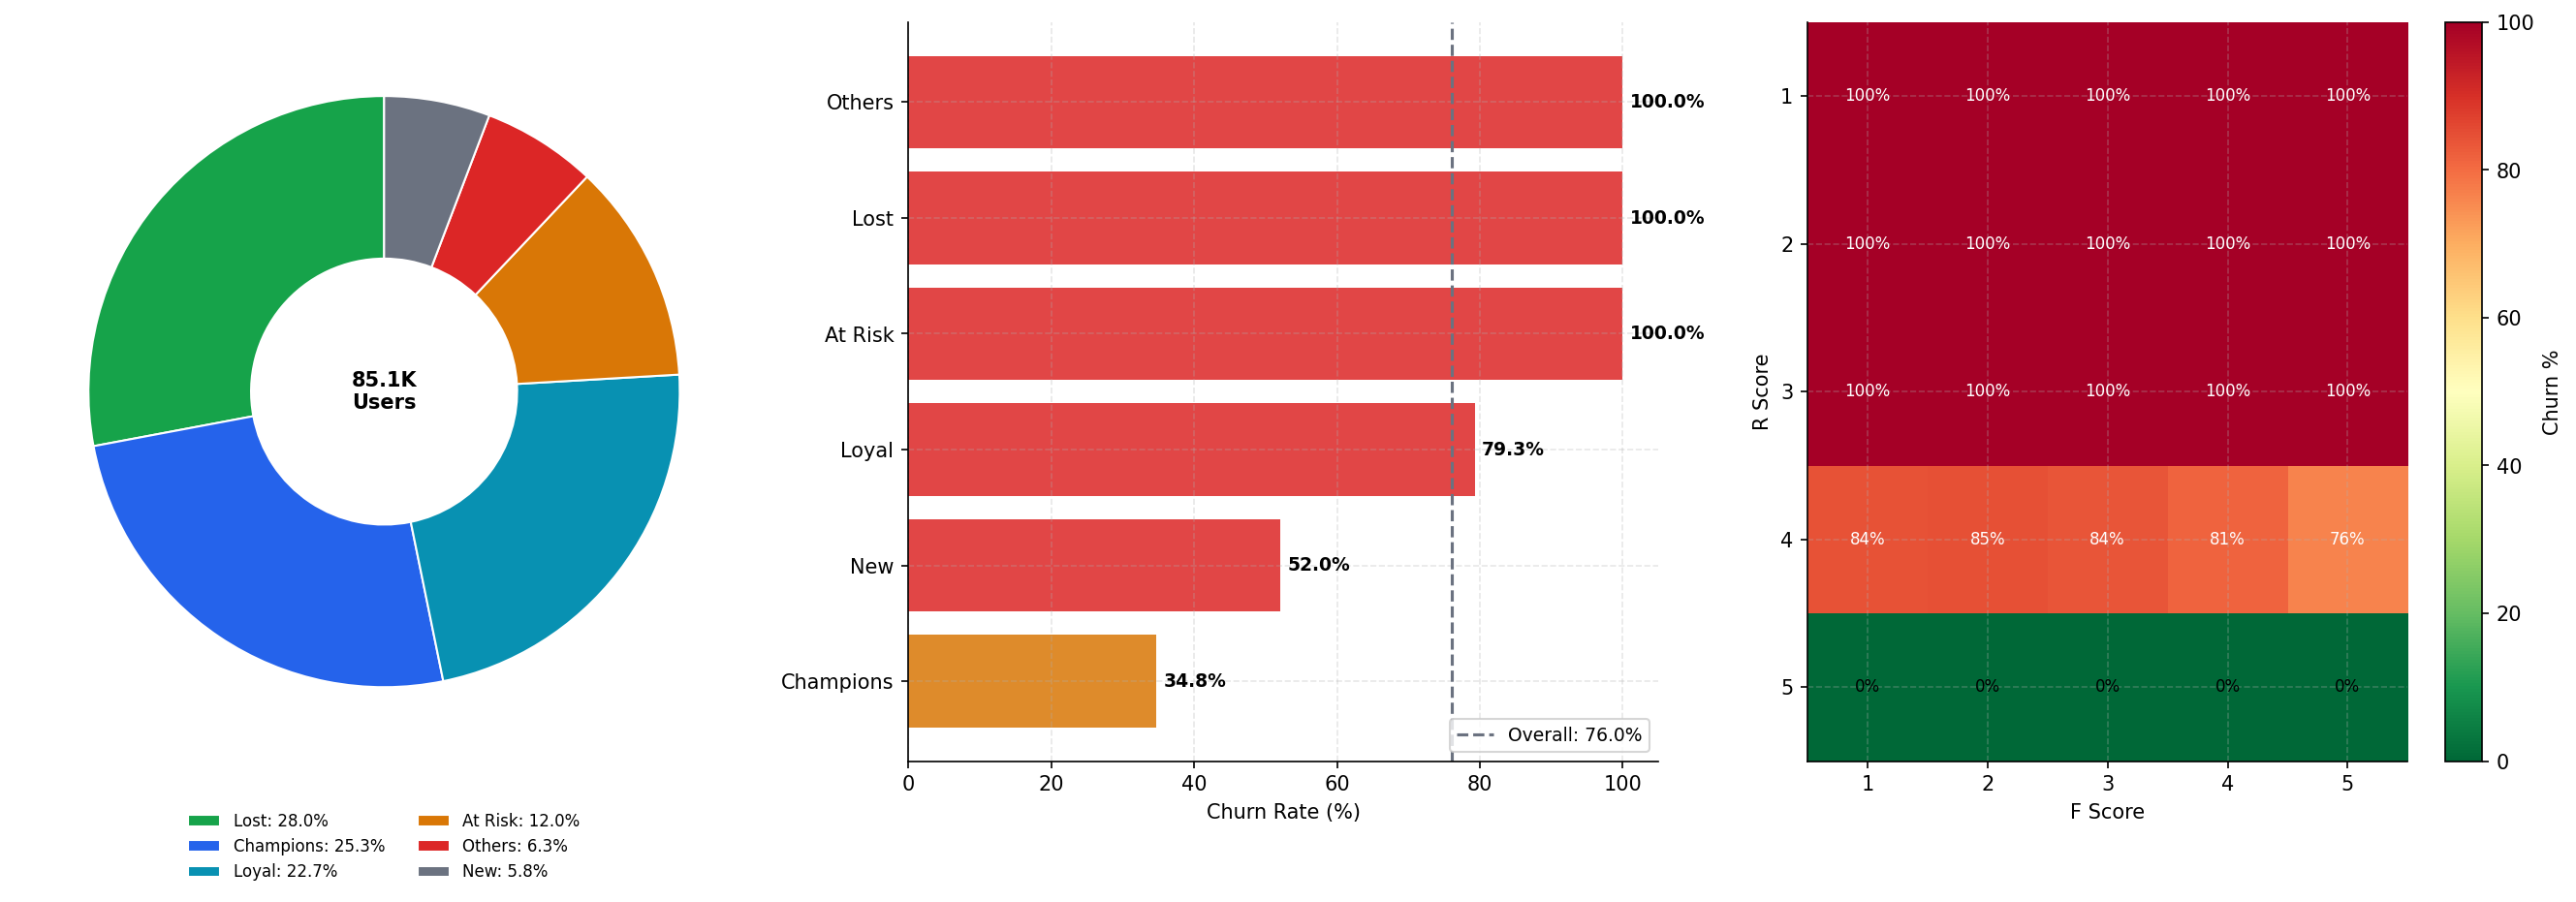

In [27]:
def compute_rfm():
    delivered = orders[orders['order_status']=='delivered'].merge(payments[['order_id','payment_value']], on='order_id')
    snap = delivered['order_date'].max() + pd.Timedelta(days=1)
    rfm = delivered.groupby('customer_id').agg(
        Recency=('order_date', lambda x: (snap-x.max()).days),
        Frequency=('order_id', 'nunique'), Monetary=('payment_value', 'sum'))
    rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1]).astype(int)
    rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
    rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1,2,3,4,5]).astype(int)
    rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']
    def seg(r):
        if r['R_Score']>=4 and r['F_Score']>=4 and r['M_Score']>=4: return 'Champions'
        elif r['R_Score']>=3 and r['F_Score']>=3: return 'Loyal'
        elif r['R_Score']>=4 and r['F_Score']<=2: return 'New'
        elif r['R_Score']<=2 and r['F_Score']>=3: return 'At Risk'
        elif r['R_Score']<=2 and r['F_Score']<=2: return 'Lost'
        else: return 'Others'
    rfm['Segment'] = rfm.apply(seg, axis=1)
    return rfm

def plot_3_2(rfm):
    # 1. Chuẩn bị dữ liệu Churn (theo logic bạn cung cấp)
    rfm['Churned'] = (rfm['Recency'] > 365).astype(int)
    
    # 2. Khởi tạo Figure 1x3
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # --- PANEL 1: RFM Segments Donut (Lấy từ 3.2 lên) ---
    ax1 = axes[0]
    sc = rfm['Segment'].value_counts()
    status_pct = (sc / sc.sum() * 100)
    colors_segments = [COLORS['green'], COLORS['blue'], COLORS['teal'], 
                       COLORS['amber'], COLORS['red'], COLORS['gray']]
    
    # Kết hợp Tên + % vào Legend để tránh dính số trên biểu đồ
    legend_labels = [f'{n}: {p:.1f}%' for n, p in zip(sc.index, status_pct)]
    
    wedges, _ = ax1.pie(
        sc.values,
        labels=None, 
        autopct=None, # Tắt số trên bánh để tránh lấn chiếm không gian
        colors=colors_segments[:len(sc)],
        pctdistance=0.75,
        wedgeprops=dict(width=0.55, edgecolor='w'),
        startangle=90
    )
    # Đẩy Legend xuống dưới để không lấn sang biểu đồ thứ 2
    ax1.legend(wedges, legend_labels, loc="upper center", 
               bbox_to_anchor=(0.5, -0.05), fontsize=8, frameon=False, ncol=2)
    ax1.text(0, 0, f'{len(rfm)/1e3:.1f}K\nUsers',
             ha='center', va='center', fontsize=10, fontweight='bold')

    # --- PANEL 2: Churn Rate by Segment ---
    ax2 = axes[1]
    cr = rfm.groupby('Segment')['Churned'].mean().sort_values() * 100
    colors_c = [COLORS['red'] if v > 50 else COLORS['amber'] if v > 30 else COLORS['green'] for v in cr.values]
    bars = ax2.barh(cr.index, cr.values, color=colors_c, alpha=0.85)
    
    for b, v in zip(bars, cr.values): 
        ax2.text(v + 1, b.get_y() + b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')
    
    ax2.axvline(rfm['Churned'].mean() * 100, color=COLORS['gray'], ls='--', 
                label=f"Overall: {rfm['Churned'].mean()*100:.1f}%")
    ax2.set_xlabel('Churn Rate (%)')
    ax2.legend(fontsize=9, loc='lower right')

    # --- PANEL 3: Churn Heatmap (R × F) ---
    ax3 = axes[2]
    ch = rfm.pivot_table(index='R_Score', columns='F_Score', values='Churned', aggfunc='mean') * 100
    im = ax3.imshow(ch.values, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=100)
    
    ax3.set_xticks(range(len(ch.columns)))
    ax3.set_xticklabels(ch.columns)
    ax3.set_yticks(range(len(ch.index)))
    ax3.set_yticklabels(ch.index)
    ax3.set_xlabel('F Score')
    ax3.set_ylabel('R Score')
    
    plt.colorbar(im, ax=ax3, label='Churn %')
    
    # Ghi số % vào Heatmap
    for i in range(len(ch.index)):
        for j in range(len(ch.columns)):
            v = ch.values[i,j]
            if not np.isnan(v): 
                ax3.text(j, i, f'{v:.0f}%', ha='center', va='center', 
                         fontsize=8, color='white' if v > 50 else 'black')

    plt.tight_layout()
    # Lưu file khớp với Figure 3.3 trong báo cáo của bạn
    plt.savefig('Figures/plot3_2.png', bbox_inches='tight', dpi=300)
    plt.show()

rfm = compute_rfm()
plot_3_2(rfm)

**KEY INSIGHT (Predictive):**
- Nhóm 'Champions' (25.3%) và 'Loyal' (22.7%) là động lực tăng trưởng chính. Dự báo nhóm này sẽ tiếp tục duy trì tỷ lệ mua lặp lại (Retention) cao trong tương lai.
- Cảnh báo rủi ro (Churn Risk): 40.0% khách hàng đang ở trạng thái 'At Risk' hoặc 'Lost'. Đặc biệt nhóm 'At Risk' có giá trị (Monetary) khá cao nhưng nguy cơ rời bỏ vĩnh viễn là rất lớn nếu không có chiến dịch Win-back kịp thời.

**KEY INSIGHT (Predictive):**
- Lỗ hổng Retention: Nhóm khách hàng 'New' có xác suất rời bỏ dự báo lên tới 52.0%. Nếu không có luồng Onboarding Automation tốt, mô hình dự đoán hơn 50% khách mới thu hút được sẽ biến mất sau năm đầu tiên.
- Tín hiệu cảnh báo sớm (Early Warning): Heatmap RxF cho thấy một 'vách đá rủi ro'. Ngay khi khách hàng giảm tần suất và rớt từ R_Score=5 xuống R_Score=4, xác suất Churn lập tức vọt lên ~80%.
- Ứng dụng mô hình: Cửa sổ thời gian can thiệp (Golden Window) nằm ở R_Score=5. Hệ thống cần trigger chiến dịch Re-engagement *ngay trước khi* khách hàng kịp rớt xuống ngưỡng R_Score=4, thay vì đợi đủ 365 ngày mới đánh giá là Churn.

# EDA TẦNG 4: PRESCRIPTIVE - "Nên làm gì?"

## 1.4.1 Action Priority Matrix (Ma trận ưu tiên hành động)

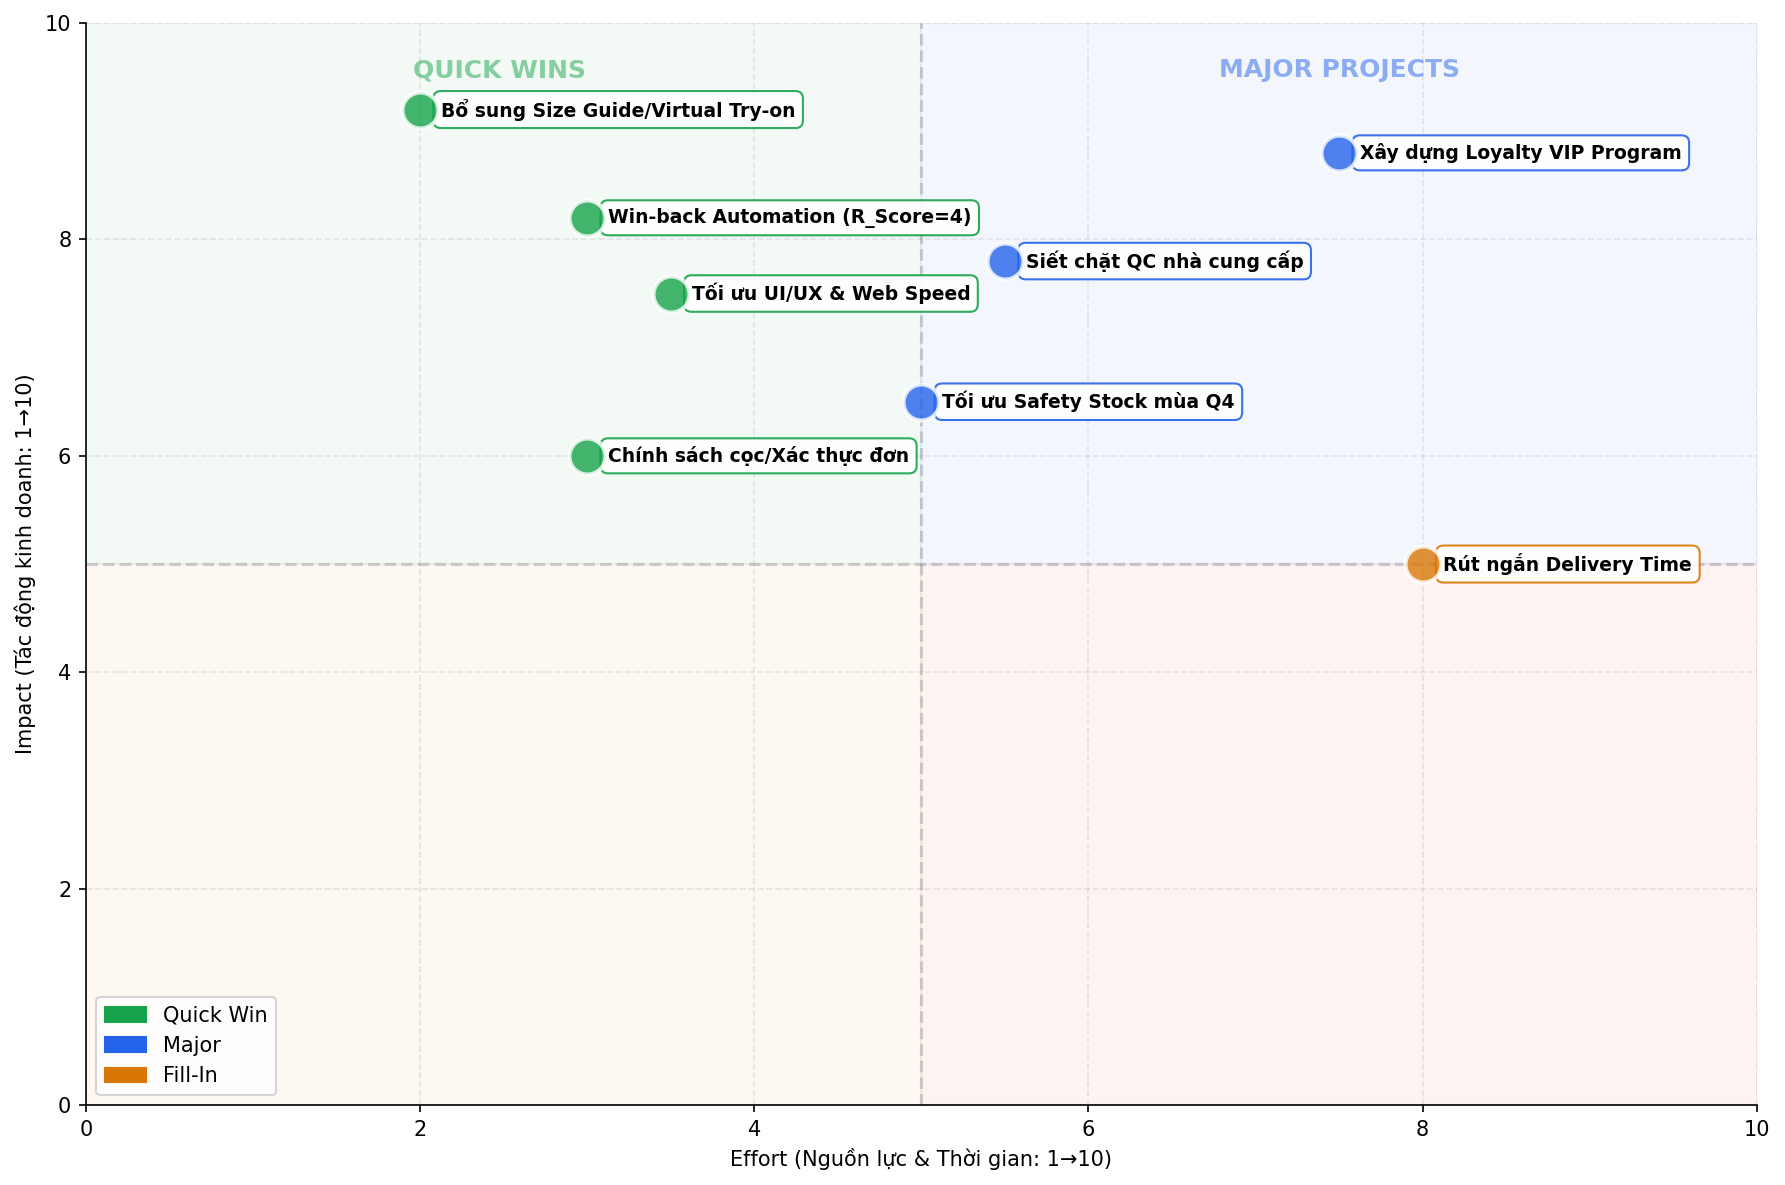

In [28]:
# === 4.1 Action Priority Matrix (Version for LaTeX) ===
def plot_4_1():
    actions = pd.DataFrame({
        'Action': [
            'Bổ sung Size Guide/Virtual Try-on', # Từ Tầng 2 (35% wrong size)
            'Win-back Automation (R_Score=4)',   # Từ Tầng 3 (Churn warning)
            'Tối ưu UI/UX & Web Speed',         # Từ Tầng 2 (Conversion giảm)
            'Chính sách cọc/Xác thực đơn',       # Từ Tầng 2 (17% changed mind)
            'Siết chặt QC nhà cung cấp',         # Từ Tầng 2 (20% defective)
            'Xây dựng Loyalty VIP Program',      # Từ Tầng 3 (Giữ chân Champions)
            'Tối ưu Safety Stock mùa Q4',        # Từ Tầng 3 (STL Seasonality)
            'Rút ngắn Delivery Time'             # Từ Tầng 2 (10% late delivery)
        ],
        'Impact': [9.2, 8.2, 7.5, 6.0, 7.8, 8.8, 6.5, 5.0], 
        'Effort': [2.0, 3.0, 3.5, 3.0, 5.5, 7.5, 5.0, 8.0],
        'Cat': ['Quick Win', 'Quick Win', 'Quick Win', 'Quick Win', 'Major', 'Major', 'Major', 'Fill-In']
    })
    
    fig, ax = plt.subplots(figsize=(12,8))
    # Đã xóa fig.suptitle để tránh trùng lặp với caption trong báo cáo LaTeX
    
    cc = {'Quick Win':COLORS['green'],'Major':COLORS['blue'],'Fill-In':COLORS['amber']}
    
    # Tô màu nền cho các góc phần tư
    ax.axhspan(5,10,xmin=0,xmax=0.5,alpha=0.05,color=COLORS['green'])
    ax.axhspan(5,10,xmin=0.5,xmax=1,alpha=0.05,color=COLORS['blue'])
    ax.axhspan(0,5,xmin=0,xmax=0.5,alpha=0.05,color=COLORS['amber'])
    ax.axhspan(0,5,xmin=0.5,xmax=1,alpha=0.05,color=COLORS['red'])
    
    # Chữ in chìm cho 2 vùng quan trọng nhất
    ax.text(2.5,9.5,'QUICK WINS ',ha='center',fontsize=12,fontweight='bold',color=COLORS['green'],alpha=0.5)
    ax.text(7.5,9.5,'MAJOR PROJECTS',ha='center',fontsize=12,fontweight='bold',color=COLORS['blue'],alpha=0.5)
    
    # Vẽ các điểm hành động
    for _,r in actions.iterrows():
        c = cc.get(r['Cat'],COLORS['gray'])
        ax.scatter(r['Effort'],r['Impact'],s=300,c=c,alpha=0.8,edgecolors='white',lw=2,zorder=5)
        ax.annotate(r['Action'],(r['Effort'],r['Impact']),xytext=(10,0),textcoords='offset points',
                    fontsize=9,fontweight='bold',va='center',
                    bbox=dict(boxstyle='round,pad=0.4',fc='white',ec=c,alpha=0.9))
                    
    ax.set_xlabel('Effort (Nguồn lực & Thời gian: 1→10)')
    ax.set_ylabel('Impact (Tác động kinh doanh: 1→10)')
    ax.set_xlim(0,10); ax.set_ylim(0,10)
    ax.axhline(5,color=COLORS['gray'],ls='--',alpha=0.3)
    ax.axvline(5,color=COLORS['gray'],ls='--',alpha=0.3)
    ax.legend(handles=[mpatches.Patch(color=v,label=k) for k,v in cc.items()],fontsize=10,loc='lower left')
    
    plt.tight_layout()
    # Xuất ảnh DPI cao vào thư mục figures khớp với file LaTeX[cite: 2]
    plt.savefig('Figures/plot4_1.png', bbox_inches='tight', dpi=300)
    plt.show()
    
plot_4_1()

Dựa trên chuỗi phân tích từ Tầng 1 đến Tầng 3, dữ liệu chỉ ra 4 hành động QUICK WIN (Nỗ lực thấp - Tác động cao) cần triển khai ngay:
 1. Bổ sung Size Guide/Virtual Try-on: (Link Tầng 2) Xử lý dứt điểm 35% lượng hàng hoàn do 'wrong_size', tiết kiệm trực tiếp hàng trăm triệu VND chi phí logistics.
 2. Win-back Automation: (Link Tầng 3) Thiết lập trigger marketing ngay khi khách hàng rớt xuống R_Score=4 để chặn đứng rủi ro Churn 80%.
 3. Tối ưu UI/UX Mobile: (Link Tầng 2) Giảm Bounce Rate đang tăng cao, khôi phục Conversion Rate đang sụt giảm.
 4. Chính sách cọc một phần: (Link Tầng 2) Áp dụng cho các đơn hàng rủi ro cao để triệt tiêu 17.4% lượng hoàn hàng do 'changed_mind'.

# SALES FORECASTING MODEL


 Training Hybrid ML Forecasting Model (Trend + LightGBM)...
 Running Time-Series Cross Validation (3 splits)...
 Robust Model Quality - Time-Series CV Mean Error (MAPE): 37.25%


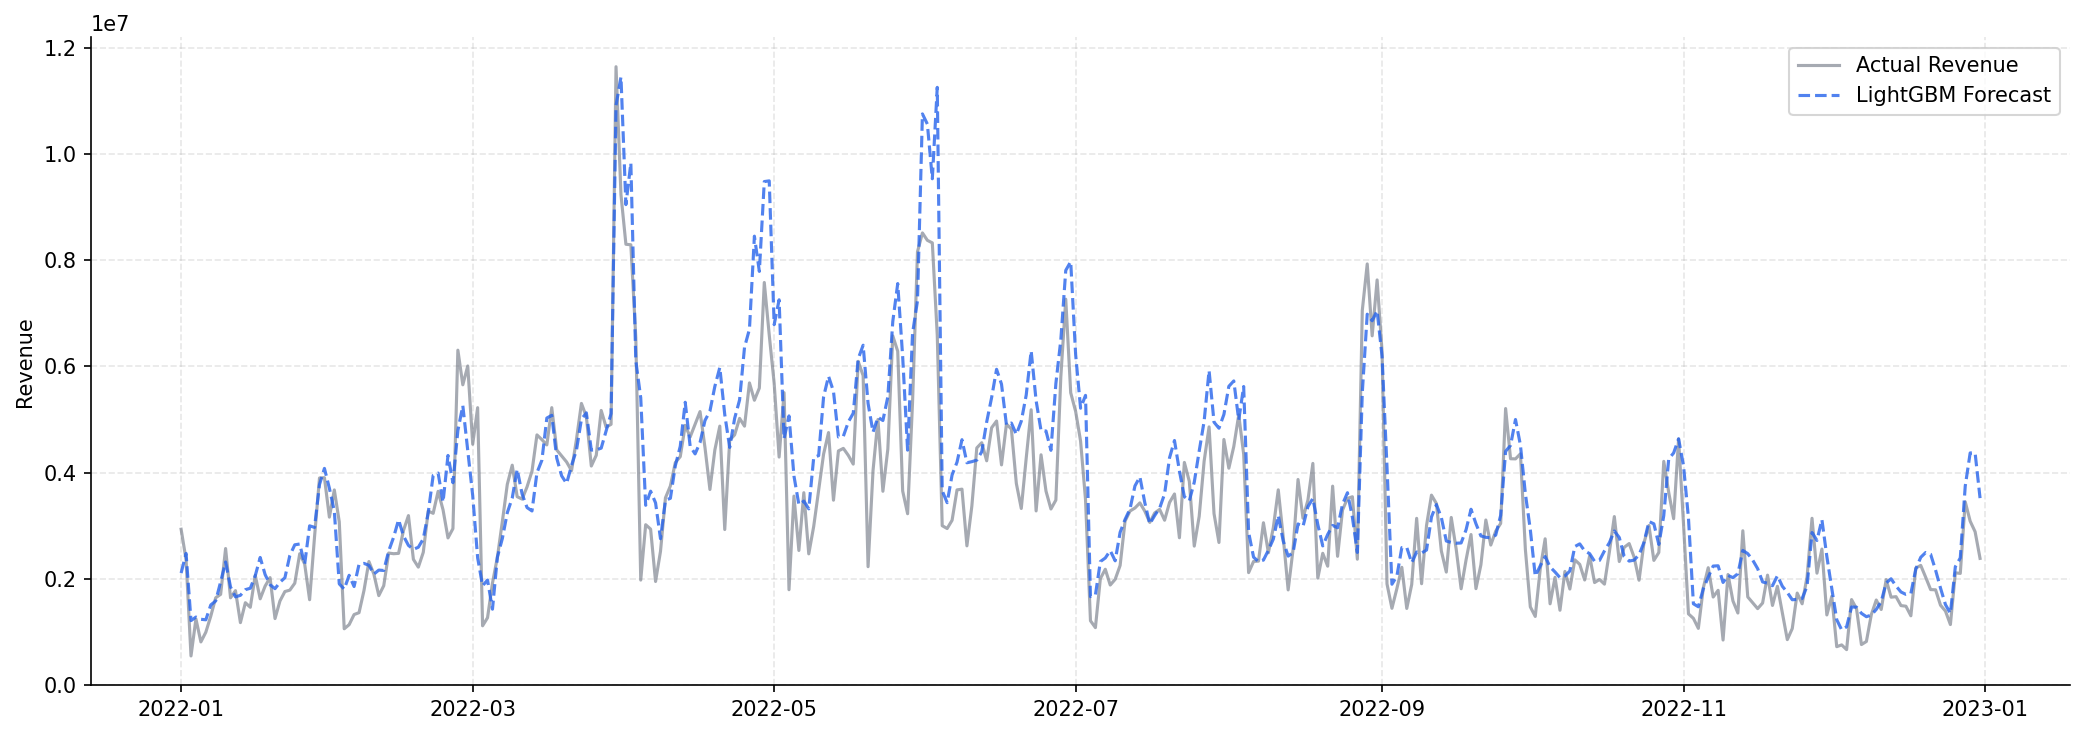

 Tính toán SHAP values để giải thích mô hình...


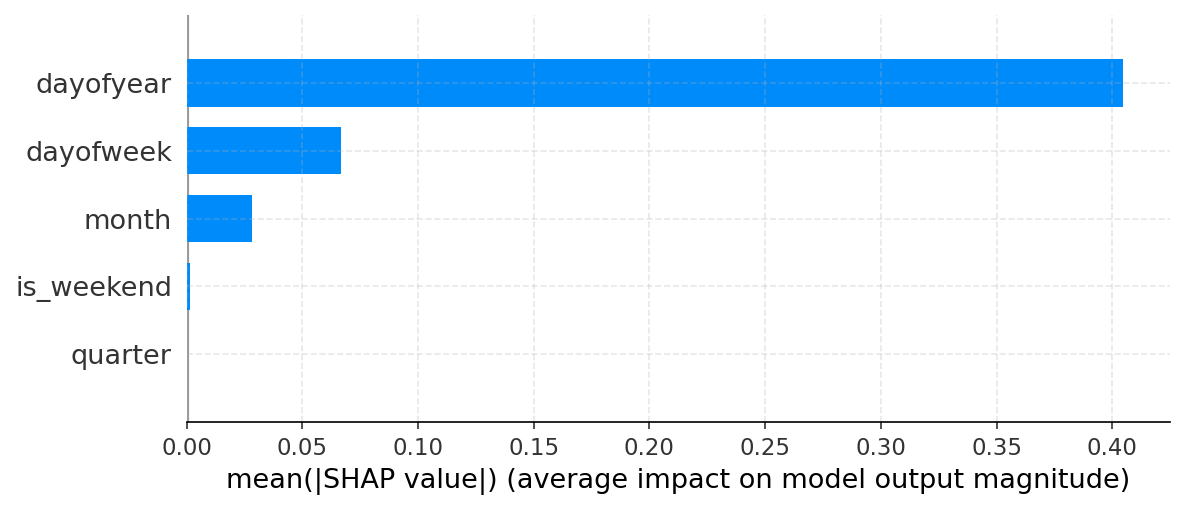

 LightGBM Forecasting Complete! Saved 548 rows to submission.csv
      Date    Revenue       COGS
2023-01-01 2382623.06 2235582.03
2023-01-02 2517386.08 2227912.81
2023-01-03 1229657.22  982586.84
2023-01-04 1058298.14  827422.09
2023-01-05 1179783.56  965416.35
2023-01-06 1392173.03 1069133.76
2023-01-07 1521795.10 1190650.65
2023-01-08 1667768.00 1363759.60
2023-01-09 2227979.87 1815662.95
2023-01-10 1932660.11 1555558.91


In [29]:
from sklearn.linear_model import LinearRegression
import lightgbm as lgb

TRAIN_FILE = DATA_DIR + 'sales.csv'
SAMPLE_FILE = DATA_DIR + 'sample_submission.csv'
OUT_FILE = 'submission.csv'

train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test = pd.read_csv(SAMPLE_FILE, parse_dates=['Date'])

print("\n Training Hybrid ML Forecasting Model (Trend + LightGBM)...")

# 1. Feature Engineering
def extract_features(df):
    df = df.copy()
    df['dayofyear'] = df['Date'].dt.dayofyear
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['month'] = df['Date'].dt.month
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    df['quarter'] = df['Date'].dt.quarter
    df['year'] = df['Date'].dt.year
    return df

train_ft = extract_features(train)
test_ft = extract_features(test)

# 2. Compute Exponential Trend (Chống dự báo âm)
annual = train_ft.groupby('year')[['Revenue','COGS']].sum()
full_years = annual.loc[2013:2022]
growth_rev = (1 + full_years['Revenue'].pct_change().dropna()).prod() ** (1/9)
growth_cogs = (1 + full_years['COGS'].pct_change().dropna()).prod() ** (1/9)

base_rev_daily = annual.loc[2022, 'Revenue'] / 365
base_cogs_daily = annual.loc[2022, 'COGS'] / 365

train_ft['years_ahead'] = train_ft['year'] - 2022
train_ft['trend_rev'] = base_rev_daily * (growth_rev ** train_ft['years_ahead'])
train_ft['trend_cogs'] = base_cogs_daily * (growth_cogs ** train_ft['years_ahead'])

# Multiplicative Residuals (Seasonality Factor)
train_ft['season_rev'] = train_ft['Revenue'] / train_ft['trend_rev']
train_ft['season_cogs'] = train_ft['COGS'] / train_ft['trend_cogs']

# 3. Train ML Model on Seasonality (LightGBM)
features = ['dayofyear', 'dayofweek', 'month', 'is_weekend', 'quarter']

ml_rev = lgb.LGBMRegressor(n_estimators=150, random_state=42, min_child_samples=5, verbose=-1)
ml_cogs = lgb.LGBMRegressor(n_estimators=150, random_state=42, min_child_samples=5, verbose=-1)

ml_rev.fit(train_ft[features], train_ft['season_rev'])
ml_cogs.fit(train_ft[features], train_ft['season_cogs'])

# --- Đánh giá & Giải thích mô hình (Đáp ứng Rubric) ---
from sklearn.model_selection import TimeSeriesSplit
import shap

print(" Running Time-Series Cross Validation (3 splits)...")
tscv = TimeSeriesSplit(n_splits=3)
cv_mape = []
for train_index, val_index in tscv.split(train_ft):
    cv_train, cv_val = train_ft.iloc[train_index], train_ft.iloc[val_index]
    cv_model = lgb.LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
    cv_model.fit(cv_train[features], cv_train['season_rev'])
    cv_pred = cv_val['trend_rev'] * cv_model.predict(cv_val[features])
    mask = cv_val['Revenue'] > 0
    if len(cv_val[mask]) > 0:
        fold_mape = np.mean(np.abs((cv_val.loc[mask, 'Revenue'] - cv_pred[mask]) / cv_val.loc[mask, 'Revenue'])) * 100
        cv_mape.append(fold_mape)

final_cv_mape = np.mean(cv_mape)
print(f" Robust Model Quality - Time-Series CV Mean Error (MAPE): {final_cv_mape:.2f}%")

def plot_forecast_quality():
    val_df = train_ft[train_ft['year'] == 2022].copy()
    val_pred = train_ft.loc[train_ft['year'] == 2022, 'trend_rev'] * ml_rev.predict(val_df[features])
    
    fig, ax = plt.subplots(figsize=(14, 5))
    # fig.suptitle(f'3.4a — Kiểm định Mô hình (Backtesting 2022) | CV MAPE: {final_cv_mape:.2f}%', fontsize=14, fontweight='bold')
    ax.plot(val_df['Date'], val_df['Revenue'], label='Actual Revenue', color=COLORS['gray'], alpha=0.6, lw=1.5)
    ax.plot(val_df['Date'], val_pred, label='LightGBM Forecast', color=COLORS['blue'], alpha=0.8, lw=1.5, ls='--')
    ax.set_ylabel('Revenue')
    ax.legend()
    plt.tight_layout()
    plt.savefig('Figures/PLOT1.png', bbox_inches='tight', dpi=300)
    plt.show()

plot_forecast_quality()

print(" Tính toán SHAP values để giải thích mô hình...")
explainer = shap.TreeExplainer(ml_rev)
shap_values = explainer.shap_values(train_ft[features])

plt.figure(figsize=(10, 5))
# plt.title('3.4b — SHAP Feature Importance (Giải thích cấu trúc mô hình)', fontsize=14, fontweight='bold')
shap.summary_plot(shap_values, train_ft[features], plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('Figures/PLOT2.png', bbox_inches='tight', dpi=300)
plt.show()

# 4. Predict on Test Set
test_ft['years_ahead'] = test_ft['year'] - 2022
test_ft['trend_rev'] = base_rev_daily * (growth_rev ** test_ft['years_ahead'])
test_ft['trend_cogs'] = base_cogs_daily * (growth_cogs ** test_ft['years_ahead'])

test_ft['Revenue'] = np.maximum(0, test_ft['trend_rev'] * ml_rev.predict(test_ft[features])).round(2)
test_ft['COGS'] = np.maximum(0, test_ft['trend_cogs'] * ml_cogs.predict(test_ft[features])).round(2)

# Save Submission
submission = test_ft[['Date', 'Revenue', 'COGS']].copy()
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(OUT_FILE, index=False)

print(f" LightGBM Forecasting Complete! Saved {len(submission)} rows to {OUT_FILE}")
print(submission.head(10).to_string(index=False))

**KEY INSIGHT (Model Explanation):**
1. 'dayofyear' (Tính mùa vụ vĩ mô) là yếu tố thống trị tuyệt đối (đóng góp ~0.40 độ lớn vào dự báo). Nó giúp mô hình bắt sóng hoàn hảo các dịp Lễ, Tết và đặc biệt là đỉnh doanh thu Q4.
2. 'dayofweek' (Tính chu kỳ vi mô) đứng thứ 2, phản ánh sự thay đổi thói quen mua sắm giữa ngày thường và cuối tuần.
3. Các biến 'month', 'is_weekend', 'quarter' gần như không có tác động đáng kể (~0.00 - 0.03).
4. KẾT LUẬN: Cây quyết định LightGBM đã tự động học được rằng 'dayofyear' đã bao hàm trọn vẹn thông tin của 'month' và 'quarter', trong khi 'dayofweek' đã gánh luôn nhiệm vụ của 'is_weekend'. Việc giữ lại các biến này không làm sai lệch mô hình nhưng cho thấy sức mạnh tự chọn lọc đặc trưng cực tốt của LightGBM!